<a href="https://colab.research.google.com/github/ishita332/Pixels-to-Parcels/blob/main/ishita_assignmnet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q 1.1

In [ ]:
import numpy as np
arr = np.linspace(0,20,100)
print(arr)
mean_value = np.mean(arr)
print(mean_value)
median_val = np.median(arr)
print(median_val)
std_val = np.std(arr)
print(std_val)
var_val = np.var(arr)
print(var_val)


[ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.36363636 16

Q 1.2

In [ ]:
import numpy as np
arr = np.linspace(1,36,36)
newarr = arr.reshape(4,9)
print(newarr)
newarr2 = newarr.reshape(-1)
print(newarr2)

[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.]


2.1


In [ ]:
import seaborn as sns
df = sns.load_dataset('titanic')
import pandas as pd
print("First 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe(include='all'))


First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   

In [ ]:
import seaborn as sns
import pandas as pd


df = sns.load_dataset('titanic')


missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

print("Columns with Missing Values:")
print(missing_summary)

df['age'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)


embarked_mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(embarked_mode)


deck_missing_count = df['deck'].isnull().sum()
deck_missing_percentage = round(
    (deck_missing_count / len(df)) * 100, 2
)

print("\nDeck Missing Values:", deck_missing_count)
print("Deck Missing Percentage:", deck_missing_percentage, "%")

df.drop(columns=['deck'], inplace=True)

print("\nRemaining missing values in treated columns:")
print(df[['age', 'embarked']].isnull().sum())


print("\nRemaining missing values in dataset:")
print(df.isnull().sum())

Columns with Missing Values:
             Missing Count  Missing Percentage (%)
age                    177                   19.87
embarked                 2                    0.22
deck                   688                   77.22
embark_town              2                    0.22

Deck Missing Values: 688
Deck Missing Percentage: 77.22 %

Remaining missing values in treated columns:
age         0
embarked    0
dtype: int64

Remaining missing values in dataset:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


question 3.1


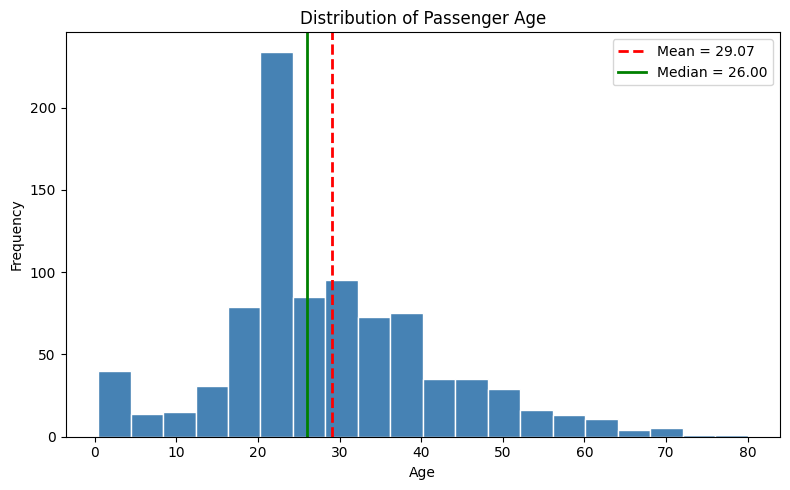

In [ ]:
import matplotlib.pyplot as plt

mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(8,5))

plt.hist(
    df['age'].dropna(),
    bins=20,
    color='steelblue',
    edgecolor='white'
)

plt.axvline(
    mean_age,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_age:.2f}'
)

plt.axvline(
    median_age,
    color='green',
    linewidth=2,
    label=f'Median = {median_age:.2f}'
)

plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

question 3.2


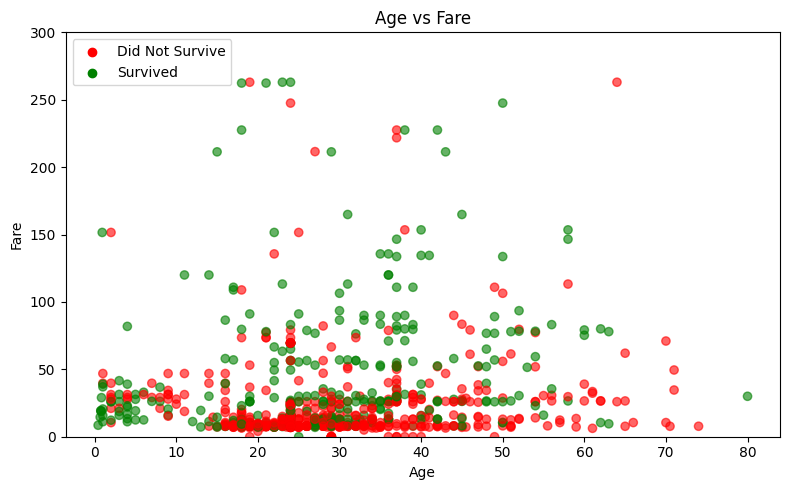

In [ ]:
import matplotlib.pyplot as plt

colors = df['survived'].map({
    0: 'red',
    1: 'green'
})

plt.figure(figsize=(8,5))

plt.scatter(
    df['age'],
    df['fare'],
    c=colors,
    alpha=0.6
)

plt.scatter([], [], c='red', label='Did Not Survive')
plt.scatter([], [], c='green', label='Survived')

plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.ylim(0, 300)

plt.legend()

plt.tight_layout()
plt.show()

question 4.1

In [66]:
import pandas as pd
df = pd.read_csv("advertising.csv")

print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [ ]:
print(df.describe())

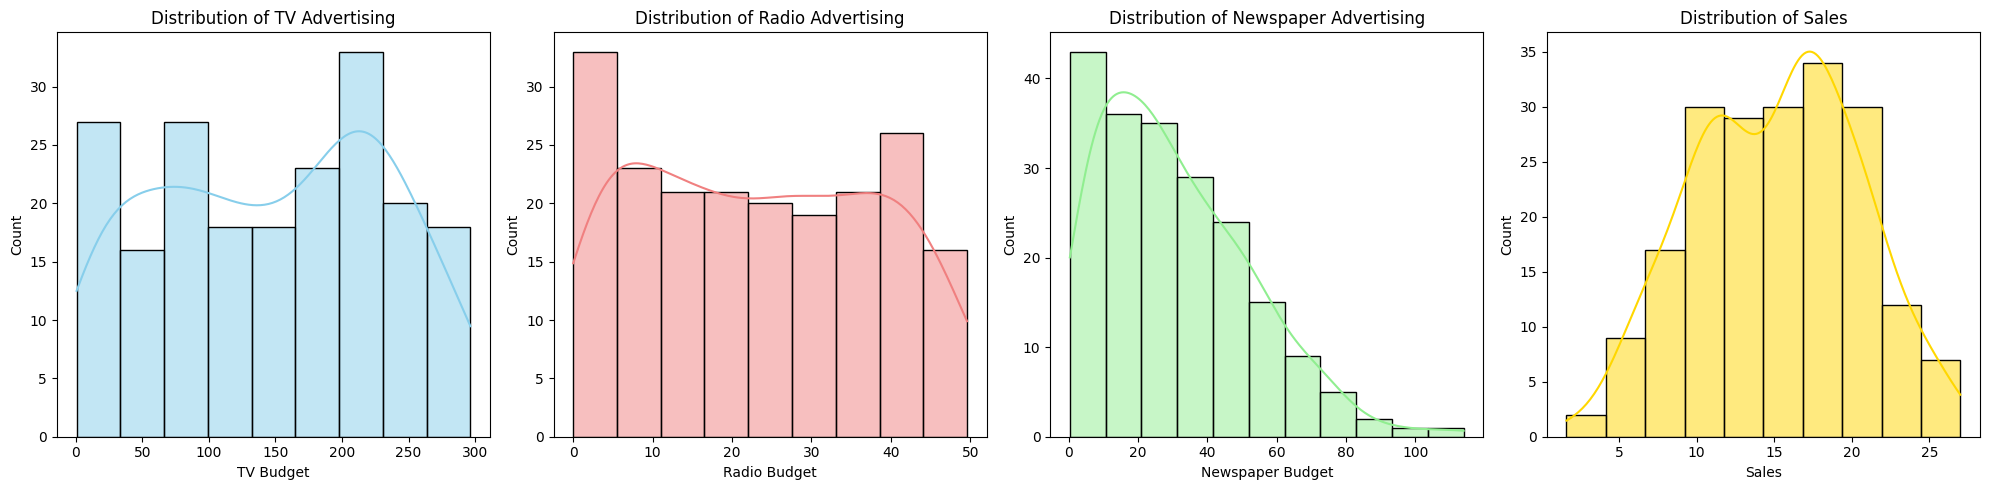

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(df['TV'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of TV Advertising')
axes[0].set_xlabel('TV Budget')

sns.histplot(df['Radio'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Radio Advertising')
axes[1].set_xlabel('Radio Budget')

sns.histplot(df['Newspaper'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Newspaper Advertising')
axes[2].set_xlabel('Newspaper Budget')

sns.histplot(df['Sales'], kde=True, ax=axes[3], color='gold')
axes[3].set_title('Distribution of Sales')
axes[3].set_xlabel('Sales')

plt.tight_layout()
plt.show()

question 4.2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
corr_matrix = df.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, # Annotate cells with correlation values
    fmt=".2f",  # Format annotations to two decimal places
    cmap="coolwarm", # Choose a colormap
    linewidths=.5 # Add lines between cells
)
plt.title('Correlation Matrix of Advertising Data')
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

# Get column names for plotting (excluding the first unnamed column if present)
columns = df.columns

# Create a 3x3 grid of scatter plots
# Using 'sns.pairplot' is a more concise way to achieve this, but to adhere to `plt.subplots(3,3)` as requested:
fig, axes = plt.subplots(len(columns), len(columns), figsize=(15, 15))

for i, col1 in enumerate(columns):
    for j, col2 in enumerate(columns):
        ax = axes[i, j]
        if i == j:
            # For diagonal, plot a histogram or KDE plot
            sns.histplot(df[col1], kde=True, ax=ax)
            ax.set_ylabel('Frequency', fontsize=10)
        else:
            sns.scatterplot(x=df[col1], y=df[col2], ax=ax)
        ax.set_xlabel(col1, fontsize=10)
        ax.set_ylabel(col2, fontsize=10)
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.suptitle('Pairwise Scatter Plots of Advertising Data', y=1.02, fontsize=16)
plt.show()

 Q5.1

In [23]:
import pandas as pd
import numpy as np
df = pd.read_csv("advertising.csv")
train_df = df.iloc[:160]
test_df = df.iloc[160:]
y_train = train_df['Sales']
y_test = test_df['Sales']

features = ['TV', 'Radio', 'Newspaper']

results = {}

for feature in features:
    x_train = train_df[feature]
    x_mean = np.mean(x_train)
    y_mean = np.mean(y_train)
    m = np.sum((x_train - x_mean) * (y_train - y_mean)) / \
        np.sum((x_train - x_mean) ** 2)
    b = y_mean - m * x_mean
    x_test = test_df[feature]
    y_pred = m * x_test + b
    mse = np.mean((y_test - y_pred) ** 2)
    results[feature] = {
        'm': m,
        'b': b,
        'mse': mse,
        'predictions': y_pred
    }
    print(f"{feature.upper()}")
    print(f"Slope (m): {m:.4f}")
    print(f"Intercept (b): {b:.4f}")
    print(f"MSE: {mse:.4f}")

    comparison = pd.DataFrame({
        'Actual Sales': y_test.values,
        'Predicted Sales': y_pred.values
    })

    print("\nFirst 5 Predictions:")
    print(comparison.head())


TV
Slope (m): 0.0557
Intercept (b): 6.9937
MSE: 5.4598

First 5 Predictions:
   Actual Sales  Predicted Sales
0          16.4        16.606425
1          13.3        11.769407
2          19.9        17.492469
3          18.0        16.104891
4          11.9        13.524776
RADIO
Slope (m): 0.1240
Intercept (b): 11.9341
MSE: 24.3078

First 5 Predictions:
   Actual Sales  Predicted Sales
0          16.4        14.178388
1          13.3        16.373040
2          19.9        14.178388
3          18.0        16.497031
4          11.9        13.756816
NEWSPAPER
Slope (m): 0.0348
Intercept (b): 13.8424
MSE: 26.7765

First 5 Predictions:
   Actual Sales  Predicted Sales
0          16.4        14.910342
1          13.3        15.557369
2          19.9        14.732932
3          18.0        14.099819
4          11.9        14.030247


question 5.2

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_reshaped = df['TV'].values.reshape(-1, 1)
y_target = df['Sales'].values
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X_reshaped, y_target, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train_sk, y_train_sk)
sk_coefficient = model.coef_[0]
sk_intercept = model.intercept_

manual_m = results['TV']['m']
manual_b = results['TV']['b']

print(f"Sklearn Coefficient (m): {sk_coefficient:.4f}")
print(f"Sklearn Intercept (b): {sk_intercept:.4f}")

print(f"Manual Coefficient (m): {manual_m:.4f}")
print(f"Manual Intercept (b): {manual_b:.4f}")


--- Scikit-learn Linear Regression (TV -> Sales) ---
Sklearn Coefficient (m): 0.0555
Sklearn Intercept (b): 7.0071

--- Manual Linear Regression (TV -> Sales) ---
Manual Coefficient (m): 0.0557
Manual Intercept (b): 6.9937


question 5.3


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_train_pred_sk = model.predict(X_train_sk)
y_test_pred_sk = model.predict(X_test_sk)
print(f"MAE (Train): {mean_absolute_error(y_train_sk, y_train_pred_sk):.4f}")
print(f"MSE (Train): {mean_squared_error(y_train_sk, y_train_pred_sk):.4f}")
print(f"RMSE (Train): {np.sqrt(mean_squared_error(y_train_sk, y_train_pred_sk)):.4f}")
print(f"R² Score (Train): {r2_score(y_train_sk, y_train_pred_sk):.4f}")
print(f"MAE (Test): {mean_absolute_error(y_test_sk, y_test_pred_sk):.4f}")
print(f"MSE (Test): {mean_squared_error(y_test_sk, y_test_pred_sk):.4f}")
print(f"RMSE (Test): {np.sqrt(mean_squared_error(y_test_sk, y_test_pred_sk)):.4f}")
print(f"R² Score (Test): {r2_score(y_test_sk, y_test_pred_sk):.4f}")

MAE (Train): 1.8005
MSE (Train): 4.9984
RMSE (Train): 2.2357
R² Score (Train): 0.8135
MAE (Test): 1.9503
MSE (Test): 6.1011
RMSE (Test): 2.4700
R² Score (Test): 0.8026


question 6.1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


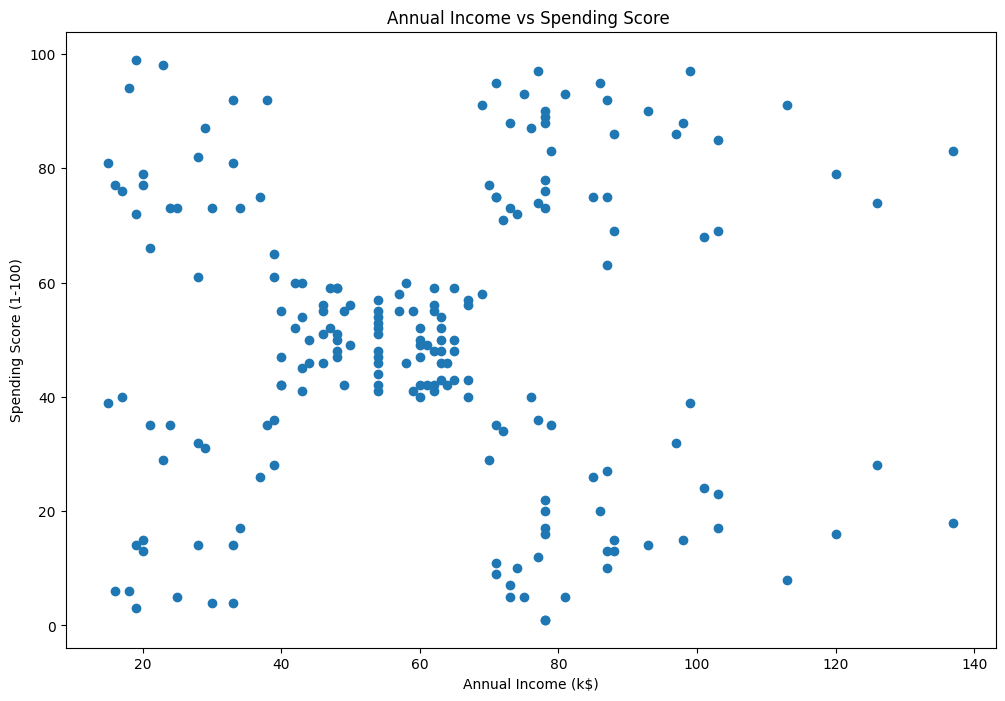

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Mall_Customers.csv")
df.head()
df.info()
df.describe()
plt.figure(figsize=(12,8))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score ')
plt.show()


i can see 5 groupings two at each left and right end and one in middle

question 6.2

optimal k is 5

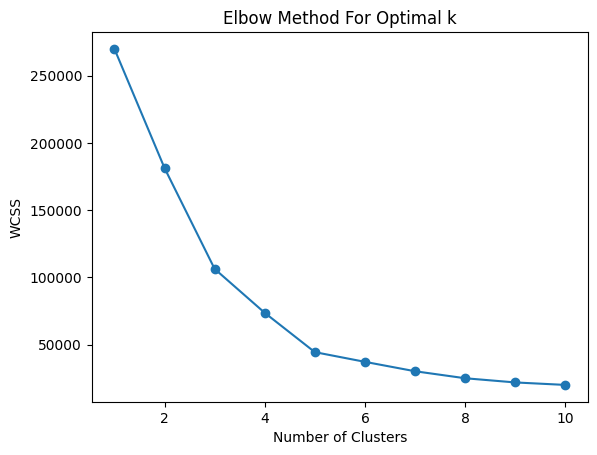

           Annual Income (k$)  Spending Score (1-100)
Cluster 0               55.30                   49.52
Cluster 1               86.54                   82.13
Cluster 2               25.73                   79.36
Cluster 3               88.20                   17.11
Cluster 4               26.30                   20.91
         Customer_count  Annual_Income_Mean  Spending_sScore_Mean
Cluster                                                          
0                    81               55.30                 49.52
1                    39               86.54                 82.13
2                    22               25.73                 79.36
3                    35               88.20                 17.11
4                    23               26.30                 20.91


In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt # Added for explicit import if not already present

wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # Added init and n_init for modern KMeans
  kmeans.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
  wcss.append(kmeans.inertia_)

# These lines must be unindentend to align with the 'for' loop and 'wcss = []'
# Added figure for better control over plot size
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method For Optimal k') # Added a title for clarity
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Annual Income (k$)','Spending Score (1-100)']])
df.head()
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=['Annual Income (k$)','Spending Score (1-100)'])
centroids.head()
centroids.index = ['Cluster 0','Cluster 1','Cluster 2','Cluster 3','Cluster 4']
print(centroids.round(2))
clustar_summary = df.groupby('Cluster').agg(
    Customer_count = ('Cluster','count'),
    Annual_Income_Mean = ('Annual Income (k$)','mean'),
    Spending_sScore_Mean = ('Spending Score (1-100)','mean'),
)
print(clustar_summary.round(2))




question 7

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


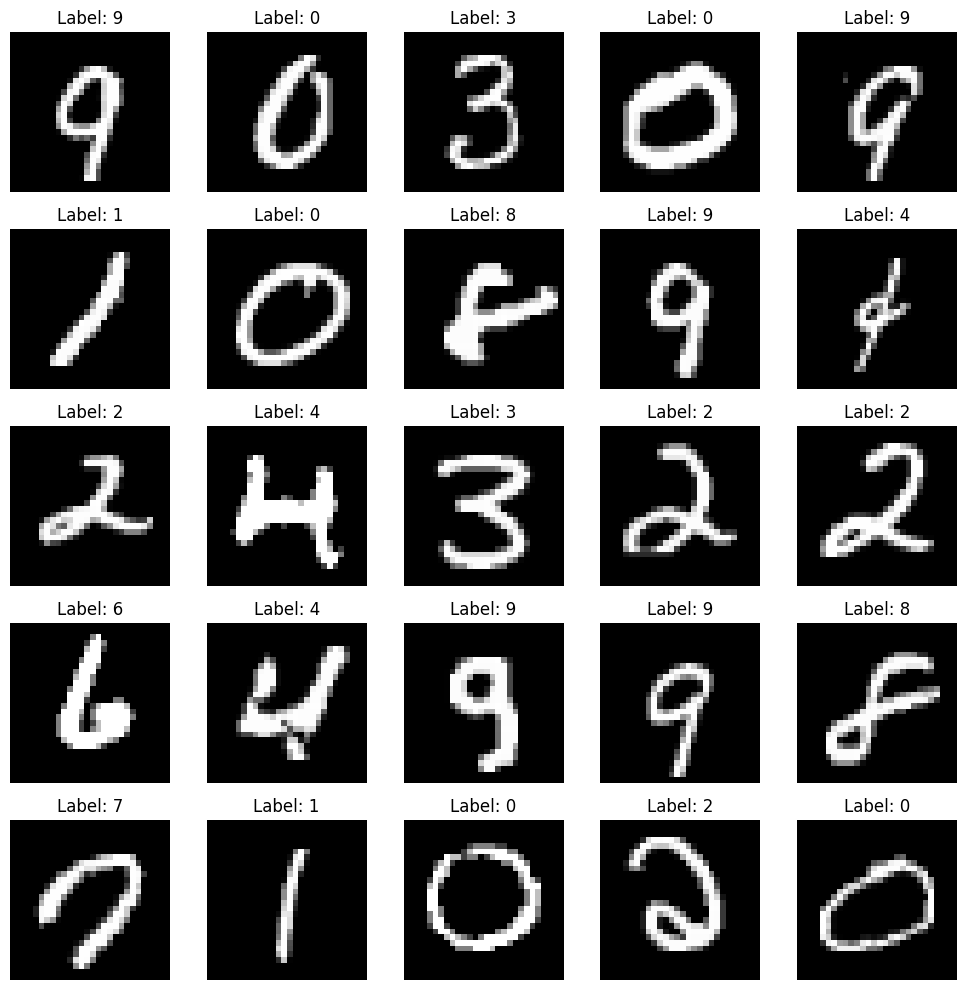

In [39]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
(X_train,y_train), (X_test,y_test) = mnist.load_data()
x_train = X_train / 255
x_test = X_test / 255
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
fig, axes = plt.subplots(5,5 ,figsize=(10,10))
random_indices = np.random.choice(x_train.shape[0], size=25, replace=False)
for i, index in enumerate(random_indices):
 current_ax = axes[i//5, i%5]
 current_ax.imshow(x_train[index], cmap='gray')
 current_ax.set_title(f'Label: {y_train[index]}')
 current_ax.axis('off')
plt.tight_layout()
plt.show()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9207 - loss: 0.2712 - val_accuracy: 0.9578 - val_loss: 0.1413
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9659 - loss: 0.1141 - val_accuracy: 0.9642 - val_loss: 0.1177
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9758 - loss: 0.0790 - val_accuracy: 0.9673 - val_loss: 0.1080
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9824 - loss: 0.0584 - val_accuracy: 0.9742 - val_loss: 0.0949
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9857 - loss: 0.0459 - val_accuracy: 0.9717 - val_loss: 0.0968
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9877 - loss: 0.0374 - val_accuracy: 0.9750 - val_loss: 0.0997
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9902 - loss: 0.0296 - val_accuracy: 0.9728 - val_loss: 0.1097
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9915 - loss: 0.0254 -

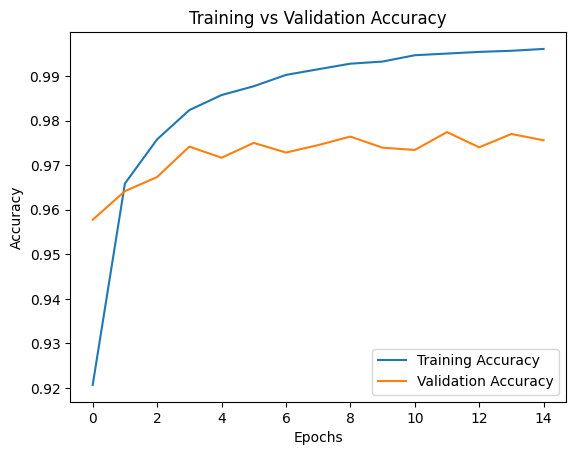

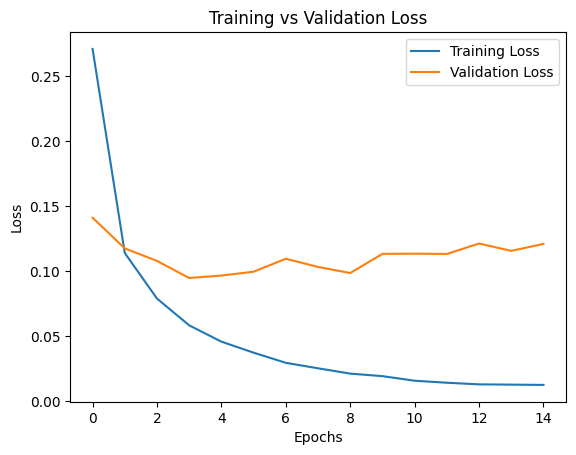

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt # Ensure matplotlib is imported

model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_split=0.2
)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

question 7.3


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.1133
Test Accuracy 0.9757999777793884
Test Loss: 0.11333553493022919
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:
[[ 971    0    0    2    1    0    2    1    1    2]
 [   1 1120    3    2    0    0    5    1    3    0]
 [   2    3 1000    1    6    0    2    9    7    2]
 [   1    1    2  989    0    5    0    2    5    5]
 [   1    0    1    1  950    1    2    2    1   23]
 [   6    0    0   15    1  859    4    1    4    2]
 [   3    2    0    0    3    2  947    0    1    0]
 [   2    6    6    2    1    0    0 1001    2    8]
 [   5    0    1    7    6    4    0    8  934    9]
 [   4    2    0    2    5    5    0    3    1  987]]


Text(0, 0.5, 'True Labels')

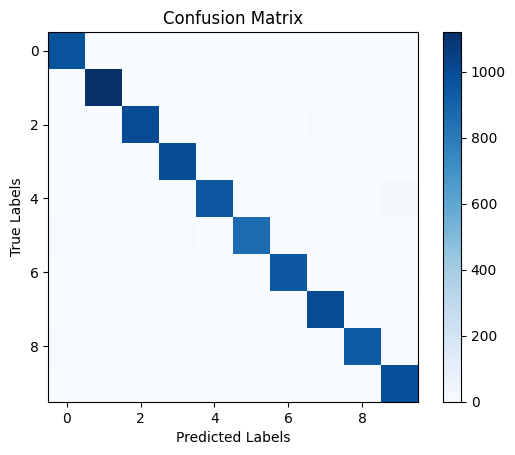

In [68]:
test_loss, test_accuracy = model.evaluate( x_test,y_test)

print("Test Accuracy", test_accuracy)
print("Test Loss:", test_loss)
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

984 and 980 , 951 and 953 and all the digits under 10 are confused i guess heatmap is the visual proof this

question 7.4

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import pandas as pd
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dense(10,activation='softmax'))
print(cnn_model.summary())

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs = 10,
    validation_split = 0.2
)

x_test_cnn = x_test.reshape(-1, 28, 28, 1)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
ff_train_acc = history.history['accuracy'][-1]
ff_val_acc = history.history['val_accuracy'][-1]
# Use the test_loss and test_accuracy from question 7.3
ff_test_loss = test_loss
ff_test_acc = test_accuracy
ff_params = model.count_params()
cnn_train_acc = cnn_history.history['accuracy'][-1]
cnn_val_acc = cnn_history.history['val_accuracy'][-1]
cnn_params = cnn_model.count_params()
comparison = pd.DataFrame({
    'Model': ['Feedforward NN', 'CNN'],
    'Parameters': [ff_params, cnn_params],
    'Train Acc': [ff_train_acc, cnn_train_acc],
    'Val Acc': [ff_val_acc, cnn_val_acc],
    'Test Acc': [ff_test_acc, cnn_test_acc],
    'Epochs': [len(history.epoch), len(cnn_history.epoch)]
})
print(comparison)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9538 - loss: 0.1488 - val_accuracy: 0.9812 - val_loss: 0.0677
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9815 - val_loss: 0.0604
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9897 - loss: 0.0324 - val_accuracy: 0.9881 - val_loss: 0.0408
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9921 - loss: 0.0235 - val_accuracy: 0.9895 - val_loss: 0.0398
Epoch 5/10
